# Setup

In [1]:
%load_ext autoreload
%autoreload 2
import gc
import logging
import sys
from pathlib import Path

import torch
from hydra.utils import instantiate


project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("huggingface_hub").setLevel(logging.WARNING)

from src.utils.notebook_setup import init_nlp_notebook  # noqa: E402


cfg = init_nlp_notebook()
cfg.paths.data_dir = str(project_root / "data")
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = instantiate(cfg.model.tokenizer).build()
print(f"Модель: {cfg.model.builder.model_name_or_path}")
print(f"Device: {device}")

NLP Environment ready. Root: c:\condratory_kaggle


c:\condratory_kaggle\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:src.core.models.tokenization:Загрузка токенизатора: cross-encoder/nli-deberta-v3-base


Модель: cross-encoder/nli-deberta-v3-base
Device: cpu


# Утилита для быстрого сравнения конфигураций LoRA

In [2]:
import pandas as pd  # noqa: E402
from peft import LoraConfig, get_peft_model  # noqa: E402


def build_lora_model(base_model, r, lora_alpha, target_modules, lora_dropout=0.05):
    """
    Оборачивает модель в LoRA с заданными параметрами.
    Возвращает модель и статистику параметров.
    """
    config = LoraConfig(
        r=r,
        lora_alpha=lora_alpha,
        target_modules=target_modules,
        lora_dropout=lora_dropout,
        bias="none",
        task_type="SEQ_CLS",
    )
    peft_model = get_peft_model(base_model, config)
    trainable, total = peft_model.get_nb_trainable_parameters()
    return peft_model, {
        "r": r,
        "alpha": lora_alpha,
        "targets": str(target_modules),
        "trainable": trainable,
        "total": total,
        "trainable_%": round(100 * trainable / total, 4),
    }


def reset_model():
    """Пересобирает чистую базовую модель без LoRA."""
    builder = instantiate(cfg.model.builder, tokenizer=tokenizer)
    # Временно отключаем peft чтобы получить чистую модель
    builder.finetuning_type = "full"
    builder.peft_config = None
    return builder.build()

# Эксперимент: сравниваем конфигурации LoRA

In [3]:
# Конфигурации которые хотим сравнить
# Для BERT: query и value — стандарт, можно добавить key и dense
experiments = [
    # (r, alpha, target_modules)
    (4,  8,  ["query_proj", "value_proj"]),
    (8,  16, ["query_proj", "value_proj"]),           # текущая конфигурация
    (16, 32, ["query_proj", "value_proj"]),
    (8,  16, ["query_proj", "key_proj", "value_proj"]),
    (8,  16, ["query_proj", "value_proj", "dense"]),  # добавляем выходные проекции
]

results = []
for r, alpha, targets in experiments:
    base = reset_model()
    _, stats = build_lora_model(base, r, alpha, targets)
    results.append(stats)
    del base
    gc.collect()

df = pd.DataFrame(results)
print("=== Сравнение конфигураций LoRA ===\n")
print(df.to_string(index=False))

INFO:src.core.models.builder:Загрузка модели из: cross-encoder/nli-deberta-v3-base
Loading weights: 100%|██████████| 202/202 [00:00<00:00, 6114.72it/s]
INFO:src.core.models.builder:Режим full: обучаем все веса модели.
INFO:src.core.models.builder:Загрузка модели из: cross-encoder/nli-deberta-v3-base
Loading weights: 100%|██████████| 202/202 [00:00<00:00, 6018.64it/s]
INFO:src.core.models.builder:Режим full: обучаем все веса модели.
INFO:src.core.models.builder:Загрузка модели из: cross-encoder/nli-deberta-v3-base
Loading weights: 100%|██████████| 202/202 [00:00<00:00, 6651.61it/s]
INFO:src.core.models.builder:Режим full: обучаем все веса модели.
INFO:src.core.models.builder:Загрузка модели из: cross-encoder/nli-deberta-v3-base
Loading weights: 100%|██████████| 202/202 [00:00<00:00, 5998.31it/s]
INFO:src.core.models.builder:Режим full: обучаем все веса модели.
INFO:src.core.models.builder:Загрузка модели из: cross-encoder/nli-deberta-v3-base
Loading weights: 100%|██████████| 202/202 [00

=== Сравнение конфигураций LoRA ===

 r  alpha                                  targets  trainable     total  trainable_%
 4      8             ['query_proj', 'value_proj']     149763 184498182       0.0812
 8     16             ['query_proj', 'value_proj']     297219 184645638       0.1610
16     32             ['query_proj', 'value_proj']     592131 184940550       0.3202
 8     16 ['query_proj', 'key_proj', 'value_proj']     444675 184793094       0.2406
 8     16    ['query_proj', 'value_proj', 'dense']    1194243 185542662       0.6436


# Проверка что LoRA применилась к правильным слоям

In [4]:

# Берём текущий конфиг из yaml
base = reset_model()
model, stats = build_lora_model(
    base,
    r=cfg.model.builder.peft_config.r,
    lora_alpha=cfg.model.builder.peft_config.lora_alpha,
    target_modules=list(cfg.model.builder.peft_config.target_modules),
)

print(f"Trainable: {stats['trainable']:,} / {stats['total']:,} ({stats['trainable_%']}%)\n")

print("Слои с LoRA адаптерами (layer 0):")
for name, _ in model.named_modules():
    if "encoder.layer.0" in name and "lora" in name.lower():
        print(f"  {name}")

print("\nЗамороженные слои (первые 5):")
frozen = [n for n, p in model.named_parameters() if not p.requires_grad]
for n in frozen[:5]:
    print(f"  {n}")
print(f"  ... и ещё {len(frozen) - 5}")

INFO:src.core.models.builder:Загрузка модели из: cross-encoder/nli-deberta-v3-base
Loading weights: 100%|██████████| 202/202 [00:00<00:00, 6340.12it/s]
INFO:src.core.models.builder:Режим full: обучаем все веса модели.


Trainable: 297,219 / 184,645,638 (0.161%)

Слои с LoRA адаптерами (layer 0):
  base_model.model.deberta.encoder.layer.0.attention.self.query_proj.lora_dropout
  base_model.model.deberta.encoder.layer.0.attention.self.query_proj.lora_dropout.default
  base_model.model.deberta.encoder.layer.0.attention.self.query_proj.lora_A
  base_model.model.deberta.encoder.layer.0.attention.self.query_proj.lora_A.default
  base_model.model.deberta.encoder.layer.0.attention.self.query_proj.lora_B
  base_model.model.deberta.encoder.layer.0.attention.self.query_proj.lora_B.default
  base_model.model.deberta.encoder.layer.0.attention.self.query_proj.lora_embedding_A
  base_model.model.deberta.encoder.layer.0.attention.self.query_proj.lora_embedding_B
  base_model.model.deberta.encoder.layer.0.attention.self.query_proj.lora_magnitude_vector
  base_model.model.deberta.encoder.layer.0.attention.self.value_proj.lora_dropout
  base_model.model.deberta.encoder.layer.0.attention.self.value_proj.lora_dropout.defa

# Sanity Check

In [5]:
from src.core.data.builder import NLPDataModule  # noqa: E402


datamodule = NLPDataModule(data_cfg=cfg.data, tokenizer=tokenizer)
datamodule.prepare_data()
datamodule.setup(stage="validate")

batch = next(iter(datamodule.val_dataloader()))
batch_gpu = {k: v.to(device) for k, v in batch.items()}

# Оборачиваем в NLPModel чтобы проверить полный forward
from src.training.module import NLPModel  # noqa: E402


nlp_model = NLPModel(model=model, optimizer_cfg=cfg.model_module.optimizer_cfg)
nlp_model.to(device)
nlp_model.eval()

with torch.no_grad():
    outputs = nlp_model(**batch_gpu)

print(f"Logits shape: {outputs.logits.shape}")  # [batch, 2]
print(f"Loss: {outputs.loss:.4f}")
print(f"Predictions: {torch.argmax(outputs.logits, dim=-1)[:8].tolist()}")
print(f"Labels:      {batch['labels'][:8].tolist()}")
print("\nFull forward pass через LoRA модель — OK")

INFO:src.core.data.builder:Начинаем загрузку и обработку сырых данных...
INFO:src.core.data.fetcher:Kaggle датасет найден локально: c:\condratory_kaggle\data/raw\train.csv. Скачивание пропущено.
Saving the dataset (1/1 shards): 100%|██████████| 1212/1212 [00:00<00:00, 173120.03 examples/s]
INFO:src.core.data.builder:Данные успешно очищены и сохранены в c:\condratory_kaggle\data/processed\nlp_dataset_cleaned_6b04af4a
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Logits shape: torch.Size([8, 3])
Loss: 7.8522
Predictions: [2, 0, 0, 2, 2, 0, 0, 1]
Labels:      [1, 2, 1, 0, 1, 1, 2, 0]

Full forward pass через LoRA модель — OK


# Эксперимент с lora_alpha / r ratio

INFO:src.core.models.builder:Загрузка модели из: cross-encoder/nli-deberta-v3-base


Прогоняем один батч для каждого alpha...



Loading weights: 100%|██████████| 202/202 [00:00<00:00, 5778.18it/s]
INFO:src.core.models.builder:Режим full: обучаем все веса модели.
INFO:src.core.models.builder:Загрузка модели из: cross-encoder/nli-deberta-v3-base


r=8, alpha=  8 (ratio=1.0): avg grad norm = 0.347169


Loading weights: 100%|██████████| 202/202 [00:00<00:00, 5830.83it/s]
INFO:src.core.models.builder:Режим full: обучаем все веса модели.
INFO:src.core.models.builder:Загрузка модели из: cross-encoder/nli-deberta-v3-base


r=8, alpha= 16 (ratio=2.0): avg grad norm = 0.668591


Loading weights: 100%|██████████| 202/202 [00:00<00:00, 5771.41it/s]
INFO:src.core.models.builder:Режим full: обучаем все веса модели.
INFO:src.core.models.builder:Загрузка модели из: cross-encoder/nli-deberta-v3-base


r=8, alpha= 32 (ratio=4.0): avg grad norm = 1.073890


Loading weights: 100%|██████████| 202/202 [00:00<00:00, 6000.56it/s]
INFO:src.core.models.builder:Режим full: обучаем все веса модели.


r=8, alpha= 64 (ratio=8.0): avg grad norm = 2.360048


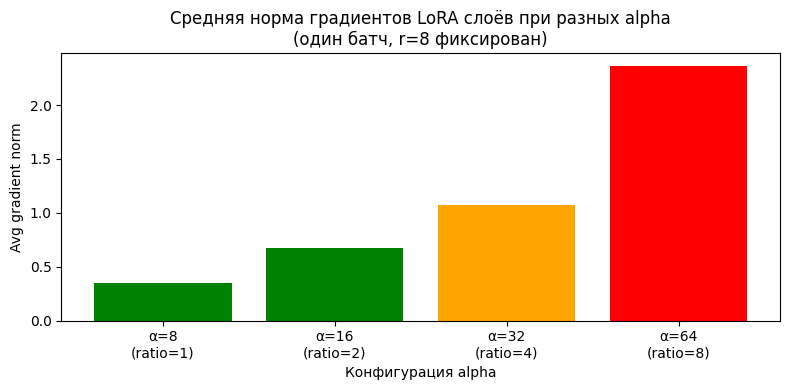


Вывод:
  ratio=1.0 (α=r):   стабильно, но медленно учится
  ratio=2.0 (α=2r):  стандарт — баланс скорости и стабильности
  ratio=4.0 (α=4r):  риск нестабильности

  Рекомендация для текущей модели: alpha=8


In [ ]:

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402


# Берём уже собранную модель из ячейки 4
# и смотрим на начальные нормы градиентов LoRA слоёв
# при разных alpha — без полного обучения, один батч

def get_lora_grad_norms(r, alpha, batch, tokenizer, cfg, device):
    base = reset_model()
    peft_m, stats = build_lora_model(base, r, alpha, ["query_proj", "value_proj", "dense"])

    nlp = NLPModel(model=peft_m, optimizer_cfg=cfg.model_module.optimizer_cfg)
    nlp.to(device).train()

    batch_gpu = {k: v.to(device) for k, v in batch.items()}
    outputs = nlp(**batch_gpu)
    outputs.loss.backward()

    grad_norms = {}
    for name, param in nlp.named_parameters():
        if param.requires_grad and param.grad is not None and "lora" in name:
            grad_norms[name.split(".")[-2]] = param.grad.norm().item()

    del nlp, peft_m, base
    gc.collect()
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

    avg_norm = np.mean(list(grad_norms.values()))
    return avg_norm, stats["trainable_%"]

ratios = [(8, 8), (8, 16), (8, 32), (8, 64)]
grad_results = []

print("Прогоняем один батч для каждого alpha...\n")
for r, alpha in ratios:
    avg_norm, pct = get_lora_grad_norms(r, alpha, batch, tokenizer, cfg, device)
    grad_results.append({"r": r, "alpha": alpha, "ratio": alpha/r,
                          "avg_grad_norm": avg_norm, "trainable_%": pct})
    print(f"r={r}, alpha={alpha:>3} (ratio={alpha/r:.1f}): "
          f"avg grad norm = {avg_norm:.6f}")

# Визуализация
fig, ax = plt.subplots(figsize=(8, 4))
ratios_vals = [d["ratio"] for d in grad_results]
norms = [d["avg_grad_norm"] for d in grad_results]
alphas = [d["alpha"] for d in grad_results]

ax.bar([f"α={a}\n(ratio={r:.0f})" for a, r in zip(alphas, ratios_vals)], norms, #noqa B905
       color=["green" if r <= 2 else "orange" if r <= 4 else "red"
              for r in ratios_vals])
ax.set_title("Средняя норма градиентов LoRA слоёв при разных alpha\n(один батч, r=8 фиксирован)")
ax.set_ylabel("Avg gradient norm")
ax.set_xlabel("Конфигурация alpha")
plt.tight_layout()
plt.show()

Выберу сбалансированный вариант с ratio=2

# Итоговая рекомендация

In [9]:
import gc
import os
import time

import psutil
import torch
from tabulate import tabulate
from torch.optim import AdamW


def quick_train_probe(target_modules, r, alpha, batch_train, cfg, device, lr=1e-3, n_steps=100):
    """
    Overfitting probe: обучает модель на одном батче N шагов с заданным LR.
    Замеряет падение Train Loss, финальную Train Acc и пиковое потребление памяти.
    """
    process = psutil.Process(os.getpid())
    start_cpu_mem = process.memory_info().rss

    base = reset_model()
    peft_m, stats = build_lora_model(base, r, alpha, target_modules)
    nlp = NLPModel(model=peft_m, optimizer_cfg=cfg.model_module.optimizer_cfg)

    is_cuda = (device == "cuda")

    if is_cuda:
        nlp.to(device)
        train_batch = {k: v.to(device) for k, v in batch_train.items()}
    else:
        train_batch = batch_train

    nlp.train()
    # Используем переданный learning rate (по умолчанию 1e-3)
    opt = AdamW([p for p in nlp.parameters() if p.requires_grad], lr=lr)

    if is_cuda:
        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()

    start_time = time.time()

    initial_loss = 0.0
    final_loss = 0.0
    final_acc = 0.0
    max_cpu_mem = start_cpu_mem

    for step in range(n_steps):
        opt.zero_grad()
        out = nlp(**train_batch)
        loss = out.loss

        if step == 0:
            initial_loss = loss.item()

        if step == n_steps - 1:
            final_loss = loss.item()
            preds = torch.argmax(out.logits, dim=-1)
            final_acc = (preds == train_batch["labels"]).float().mean().item()

        loss.backward()
        opt.step()

        if not is_cuda:
            current_mem = process.memory_info().rss
            if current_mem > max_cpu_mem:
                max_cpu_mem = current_mem

    if is_cuda:
        torch.cuda.synchronize()
        peak_mem_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
    else:
        peak_mem_mb = (max_cpu_mem - start_cpu_mem) / (1024 ** 2)

    train_time = time.time() - start_time

    del nlp, peft_m, base, out, loss
    gc.collect()
    torch.cuda.empty_cache() if is_cuda else None

    return {
        "Target Modules": "+".join(target_modules),
        "Params (%)": stats["trainable_%"],
        "Peak Mem (MB)": round(peak_mem_mb, 1),
        "Time (s)": round(train_time, 3),
        "Start Loss": round(initial_loss, 4),
        "End Loss": round(final_loss, 4),
        "Train Acc": round(final_acc, 4)
    }

# Инициализируем датасет
datamodule.setup(stage="fit")
train_iter = iter(datamodule.train_dataloader())
batch_train = next(train_iter)

configs_to_test = [
    ["query_proj", "value_proj"],
    ["query_proj", "key_proj", "value_proj"],
    ["query_proj", "value_proj", "dense"],
    ["query_proj", "key_proj", "value_proj", "dense"],
]

# Обновленные настройки теста
test_lr = 1e-3
test_steps = 100

print(f"Тестируем {len(configs_to_test)} конфигурации target_modules")
print(f"({test_steps} шагов обучения на одном батче, LR={test_lr})\n")

probe_results = []
for targets in configs_to_test:
    res = quick_train_probe(targets, r=8, alpha=16,
                            batch_train=batch_train,
                            cfg=cfg, device=device,
                            lr=test_lr, n_steps=test_steps)
    probe_results.append(res)
    print(f"  [{res['Target Modules']}] | End Loss: {res['End Loss']} | Train Acc: {res['Train Acc']}")

print("\n=== Сводная таблица мощности конфигураций (Overfitting Probe) ===")
print(tabulate(probe_results, headers="keys", tablefmt="pipe", floatfmt=".4f"))

best = min(probe_results, key=lambda x: x["End Loss"])

print("\n=== Результат ===")
print(f"Самая мощная конфигурация (минимальный End Loss): [{best['Target Modules']}]")
print(f"Снизила Loss с {best['Start Loss']} до {best['End Loss']}, Trainable = {best['Params (%)']}%, Peak Mem = {best['Peak Mem (MB)']} MB")

print("\nЗапиши в configs/model/builder/default.yaml:")
print(f"  target_modules: {best['Target Modules'].split('+')}")

INFO:src.core.data.builder:DataModule.setup уже инициализирован, пропускаем повторный вызов.
INFO:src.core.models.builder:Загрузка модели из: cross-encoder/nli-deberta-v3-base


Тестируем 4 конфигурации target_modules
(100 шагов обучения на одном батче, LR=0.001)



Loading weights: 100%|██████████| 202/202 [00:00<00:00, 6465.13it/s]
INFO:src.core.models.builder:Режим full: обучаем все веса модели.
INFO:src.core.models.builder:Загрузка модели из: cross-encoder/nli-deberta-v3-base


  [query_proj+value_proj] | End Loss: 0.0005 | Train Acc: 1.0


Loading weights: 100%|██████████| 202/202 [00:00<00:00, 5611.18it/s]
INFO:src.core.models.builder:Режим full: обучаем все веса модели.
INFO:src.core.models.builder:Загрузка модели из: cross-encoder/nli-deberta-v3-base


  [query_proj+key_proj+value_proj] | End Loss: 0.0004 | Train Acc: 1.0


Loading weights: 100%|██████████| 202/202 [00:00<00:00, 5614.08it/s]
INFO:src.core.models.builder:Режим full: обучаем все веса модели.
INFO:src.core.models.builder:Загрузка модели из: cross-encoder/nli-deberta-v3-base


  [query_proj+value_proj+dense] | End Loss: 0.0002 | Train Acc: 1.0


Loading weights: 100%|██████████| 202/202 [00:00<00:00, 5422.43it/s]
INFO:src.core.models.builder:Режим full: обучаем все веса модели.


  [query_proj+key_proj+value_proj+dense] | End Loss: 0.0001 | Train Acc: 1.0

=== Сводная таблица мощности конфигураций (Overfitting Probe) ===
| Target Modules                       |   Params (%) |   Peak Mem (MB) |   Time (s) |   Start Loss |   End Loss |   Train Acc |
|:-------------------------------------|-------------:|----------------:|-----------:|-------------:|-----------:|------------:|
| query_proj+value_proj                |       0.1610 |       1291.9000 |   186.6190 |       6.1764 |     0.0005 |      1.0000 |
| query_proj+key_proj+value_proj       |       0.2406 |        927.4000 |   209.0940 |       5.9207 |     0.0004 |      1.0000 |
| query_proj+value_proj+dense          |       0.6436 |       1358.6000 |   244.3110 |       5.9017 |     0.0002 |      1.0000 |
| query_proj+key_proj+value_proj+dense |       0.7225 |        986.0000 |   257.6080 |       5.6413 |     0.0001 |      1.0000 |

=== Результат ===
Самая мощная конфигурация (минимальный End Loss): [query_proj+k

На самом деле все конфигурации для данной задачи показали полное обучение поэтому можно брать самую минимальную для сохранения ресурсов